# VQA Baseline v2 — Qwen2.5-VL + LoRA + 4bit 양자화 (Colab)
- 환경: Google Colab (T4 / A100)
- 모델: `Qwen/Qwen2.5-VL-3B-Instruct`
- 데이터: Google Drive 마운트 후 사용

## 0. GPU 확인

In [75]:
!nvidia-smi

Thu Apr  2 03:07:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             31W /   70W |   14049MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. 패키지 설치

In [76]:
# !pip install transformers accelerate peft bitsandbytes datasets pillow qwen-vl-utils -q

## 2. Google Drive 마운트

In [77]:
# from google.colab import drive
# drive.mount('/content/drive')

# import subprocess
# subprocess.run([
#     'unzip', '-o',
#     '/content/drive/MyDrive/ssafy_ai_proj/2026-ssafy-15-2-ai.zip',
#     '-d', '/content/dataset'
# ], check=True)

# DATASET_DIR = '/content/dataset'
# print(f'데이터셋 경로: {DATASET_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
데이터셋 경로: /content/dataset


In [78]:
# DATASET_DIR은 압축 해제 후 실제 폴더명에 맞게 설정
DATASET_DIR = '/content/dataset' # ls 결과에 맞게 수정
print(f'데이터셋 경로: {DATASET_DIR}')

데이터셋 경로: /content/dataset


## 3. 라이브러리 로드

In [79]:
import os
import math
import random
import numpy as np
import pandas as pd
from pathlib import Path
from dataclasses import dataclass
from typing import Any
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig,
    get_linear_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

In [80]:
# ── 재현성 고정 ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 4. Config

In [81]:
# Config
BASE_DIR  = Path(DATASET_DIR)         # /content/dataset
TRAIN_CSV = BASE_DIR / 'train.csv'    # /content/dataset/train.csv
TEST_CSV  = BASE_DIR / 'test.csv'     # /content/dataset/test.csv
SAVE_DIR  = Path('/content/best_model')

# ── 모델 ──
MODEL_ID   = 'Qwen/Qwen2.5-VL-3B-Instruct'
IMAGE_SIZE = 336

# ── 학습 ──
TRAIN_SAMPLE_N = 100     # 파이프라인 확인용 (전체: None)
VAL_RATIO      = 0.1
BATCH_SIZE     = 1
GRAD_ACCUM     = 4
EPOCHS         = 1
LR             = 1e-4

# ── LoRA ──
LORA_R       = 8
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05

LABEL2ID = {'a': 0, 'b': 1, 'c': 2, 'd': 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

## 5. 데이터 로드

In [82]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

# 결측치 제거
train_df = train_df.dropna(subset=['answer'])
train_df = train_df[train_df['answer'].isin(['a','b','c','d'])].reset_index(drop=True)

# 누락 이미지 필터링 ← 추가
train_df = train_df[train_df['path'].apply(lambda p: (BASE_DIR / p).exists())].reset_index(drop=True)
test_df  = test_df[test_df['path'].apply(lambda p: (BASE_DIR / p).exists())].reset_index(drop=True)
print(f'필터링 후 train: {len(train_df)} | test: {len(test_df)}')

# 샘플링
if TRAIN_SAMPLE_N:
    train_df = train_df.sample(n=TRAIN_SAMPLE_N, random_state=SEED).reset_index(drop=True)

# Train / Val 분리
val_size  = int(len(train_df) * VAL_RATIO)
val_df    = train_df.sample(val_size, random_state=SEED)
train_df2 = train_df.drop(val_df.index).reset_index(drop=True)
val_df    = val_df.reset_index(drop=True)

print(f'Train: {len(train_df2)} | Val: {len(val_df)} | Test: {len(test_df)}')

필터링 후 train: 5072 | test: 5074
Train: 90 | Val: 10 | Test: 5074


## 6. 프롬프트 설계

In [83]:
SYSTEM_INSTRUCT = (
    "You are a helpful visual question answering assistant. "
    "Answer using exactly one letter among a, b, c, or d. No explanation."
)

def build_mc_prompt(question, a, b, c, d):
    return (
        f"{question}\n"
        f"(a) {a}\n(b) {b}\n(c) {c}\n(d) {d}\n\n"
        "정답을 반드시 a, b, c, d 중 하나의 소문자 한 글자로만 출력하세요."
    )

row = train_df2.iloc[0]
print(build_mc_prompt(row['question'], row['a'], row['b'], row['c'], row['d']))

사진에 보이는 재활용품 중 플라스틱 재질의 품목은 무엇인가요?
(a) 골판지 상자
(b) 종이 상자
(c) 비닐 봉투
(d) 플라스틱 트레이

정답을 반드시 a, b, c, d 중 하나의 소문자 한 글자로만 출력하세요.


## 7. Dataset & Collator

In [84]:
class VQAMCDataset(Dataset):
    def __init__(self, df, processor, base_dir, is_train=True):
        self.df        = df.reset_index(drop=True)
        self.processor = processor
        self.base_dir  = Path(base_dir)
        self.is_train  = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(self.base_dir / row['path']).convert('RGB')

        user_text = build_mc_prompt(
            str(row['question']),
            str(row['a']), str(row['b']),
            str(row['c']), str(row['d'])
        )
        messages = [
            {'role': 'system', 'content': [{'type': 'text', 'text': SYSTEM_INSTRUCT}]},
            {'role': 'user',   'content': [
                {'type': 'image', 'image': img},
                {'type': 'text',  'text': user_text}
            ]}
        ]
        if self.is_train:
            gold = str(row['answer']).strip().lower()
            messages.append({'role': 'assistant', 'content': [{'type': 'text', 'text': gold}]})

        return {'messages': messages, 'image': img,
                'answer': str(row['answer']) if self.is_train else None}


@dataclass
class DataCollator:
    processor: Any
    is_train: bool = True

    def __call__(self, batch):
        texts, images = [], []
        for sample in batch:
            text = self.processor.apply_chat_template(
                sample['messages'],
                tokenize=False,
                add_generation_prompt=False
            )
            texts.append(text)
            images.append(sample['image'])

        enc = self.processor(
            text=texts,
            images=images,
            padding=True,
            return_tensors='pt'
        )
        if self.is_train:
            enc['labels'] = enc['input_ids'].clone()
        return enc

## 8. 모델 로드 (4bit 양자화 + LoRA)

In [85]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
)

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=IMAGE_SIZE * IMAGE_SIZE,
    max_pixels=IMAGE_SIZE * IMAGE_SIZE,
    trust_remote_code=True
)

base_model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True
)

base_model = prepare_model_for_kbit_training(base_model)
base_model.gradient_checkpointing_enable()

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias='none',
    target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'],
    task_type='CAUSAL_LM'
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

trainable params: 18,576,384 || all params: 3,773,199,360 || trainable%: 0.4923


## 9. DataLoader

In [86]:
train_ds = VQAMCDataset(train_df2, processor, BASE_DIR, is_train=True)
val_ds   = VQAMCDataset(val_df,    processor, BASE_DIR, is_train=True)
test_ds  = VQAMCDataset(test_df,   processor, BASE_DIR, is_train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=DataCollator(processor, True),  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=DataCollator(processor, True),  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=DataCollator(processor, False), num_workers=2)

print(f'Train steps/epoch : {len(train_loader)}')
print(f'Val   steps/epoch : {len(val_loader)}')

Train steps/epoch : 90
Val   steps/epoch : 10


존재하는 파일만 사용

In [87]:
from pathlib import Path

# 존재하는 이미지만 필터링
def filter_existing(df, base_dir):
    mask = df['path'].apply(lambda p: (Path(base_dir) / p).exists())
    filtered = df[mask].reset_index(drop=True)
    print(f'원본: {len(df)} → 필터링 후: {len(filtered)} (누락: {len(df)-len(filtered)})')
    return filtered

train_df = filter_existing(train_df, BASE_DIR)
test_df  = filter_existing(test_df,  BASE_DIR)

원본: 100 → 필터링 후: 100 (누락: 0)
원본: 5074 → 필터링 후: 5074 (누락: 0)


## 10. Optimizer & Scheduler

In [88]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

num_training_steps = EPOCHS * math.ceil(len(train_loader) / GRAD_ACCUM)
num_warmup_steps   = int(num_training_steps * 0.03)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

scaler = torch.amp.GradScaler('cuda', enabled=True)

print(f'총 학습 스텝 : {num_training_steps} | 웜업 스텝 : {num_warmup_steps}')

총 학습 스텝 : 23 | 웜업 스텝 : 0


## 11. 학습 & 검증 루프

In [89]:
def extract_choice(text: str) -> str:
    text = text.strip().lower()
    lines = [l.strip() for l in text.splitlines() if l.strip()]
    if not lines:
        return 'a'
    last = lines[-1]
    if last in ['a','b','c','d']:
        return last
    for tok in last.split():
        if tok in ['a','b','c','d']:
            return tok
    return 'a'


def train_one_epoch(model, loader, optimizer, scheduler, scaler, epoch):
    model.train()
    running = 0.0
    avg_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(loader, desc=f'Epoch {epoch} [train]', unit='batch')
    for step, batch in enumerate(pbar, start=1):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            loss = model(**batch).loss / GRAD_ACCUM

        scaler.scale(loss).backward()
        running += loss.item()

        if step % GRAD_ACCUM == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

            avg_loss = running / GRAD_ACCUM
            pbar.set_postfix({
                'loss': f'{avg_loss:.3f}',
                'lr'  : f'{scheduler.get_last_lr()[0]:.2e}'
            })
            running = 0.0

    return avg_loss


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc='[valid]', unit='batch')
    for batch in pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            outputs = model(**batch)

        val_loss += outputs.loss.item()

        logits      = outputs.logits[:, -1, :]
        pred_ids    = logits.argmax(dim=-1)
        pred_texts  = processor.batch_decode(pred_ids.unsqueeze(-1), skip_special_tokens=True)
        labels      = batch['labels'][:, -1]
        label_texts = processor.batch_decode(labels.unsqueeze(-1),   skip_special_tokens=True)

        for pred, gold in zip(pred_texts, label_texts):
            if extract_choice(pred) == extract_choice(gold):
                correct += 1
            total += 1

    acc = correct / total if total > 0 else 0
    return val_loss / len(loader), acc

In [90]:
best_val_acc = 0
history = []

for epoch in range(1, EPOCHS + 1):
    print(f'\n[Epoch {epoch}/{EPOCHS}]')
    train_loss        = train_one_epoch(model, train_loader, optimizer, scheduler, scaler, epoch)
    val_loss, val_acc = evaluate(model, val_loader)

    history.append({
        'epoch'     : epoch,
        'train_loss': train_loss,
        'val_loss'  : val_loss,
        'val_acc'   : val_acc
    })

    print(f'  Train Loss : {train_loss:.4f}')
    print(f'  Val   Loss : {val_loss:.4f} | Val Acc : {val_acc:.4f}')
    print(f'  LR         : {scheduler.get_last_lr()[0]:.2e}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(SAVE_DIR)
        processor.save_pretrained(SAVE_DIR)
        print(f'  ✅ Best 모델 저장 (Val Acc: {best_val_acc:.4f})')

print(f'\n최종 Best Val Accuracy: {best_val_acc:.4f}')


[Epoch 1/1]


Epoch 1 [train]:   0%|          | 0/90 [00:00<?, ?batch/s]

[valid]:   0%|          | 0/10 [00:00<?, ?batch/s]

  Train Loss : 1.7794
  Val   Loss : 6.8044 | Val Acc : 1.0000
  LR         : 4.35e-06
  ✅ Best 모델 저장 (Val Acc: 1.0000)

최종 Best Val Accuracy: 1.0000


In [91]:
# # 누락 이미지 전체 체크
# missing = []
# for _, row in train_df2.iterrows():
#     path = BASE_DIR / row['path']
#     if not path.exists():
#         missing.append(row['path'])

# print(f'누락 파일 수: {len(missing)}')
# print(missing[:10])

In [92]:
# 실제 이미지 파일 위치 확인
!ls /content/dataset/train | head -5
!echo "---"
print(train_df2['path'].iloc[0])  # CSV에 저장된 경로 형태 확인

train_0001.jpg
train_0002.jpg
train_0003.jpg
train_0004.jpg
train_0005.jpg
---
train/train_3055.jpg


## 12. (선택) Best 모델 Drive에 백업

In [93]:
# Colab은 런타임 종료 시 /content 가 초기화되므로 Drive에 백업
import shutil
DRIVE_SAVE = '/content/drive/MyDrive/vqa_best_model'
shutil.copytree(SAVE_DIR, DRIVE_SAVE, dirs_exist_ok=True)
print(f'Drive 백업 완료: {DRIVE_SAVE}')

Drive 백업 완료: /content/drive/MyDrive/vqa_best_model


## 13. 학습 곡선 시각화

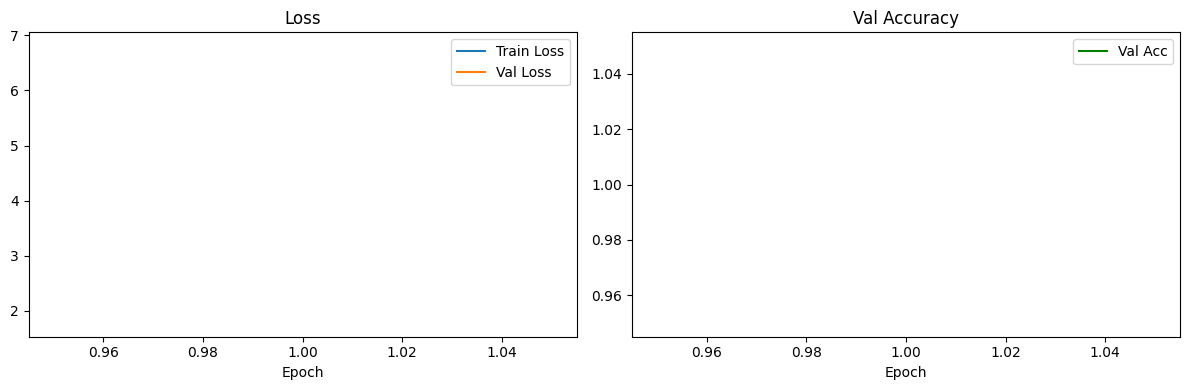

In [94]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train Loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(hist_df['epoch'], hist_df['val_acc'], label='Val Acc', color='green')
axes[1].set_title('Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 14. 추론 & 제출 파일 생성

In [ ]:
# @torch.no_grad()
# def predict(model, df, processor, base_dir):
#     model.eval()
#     preds = []

#     for i in tqdm(range(len(df)), desc='Inference', unit='sample'):
#         row = df.iloc[i]
#         img = Image.open(Path(base_dir) / row['path']).convert('RGB')
#         user_text = build_mc_prompt(
#             str(row['question']),
#             str(row['a']), str(row['b']),
#             str(row['c']), str(row['d'])
#         )
#         messages = [
#             {'role': 'system', 'content': [{'type': 'text', 'text': SYSTEM_INSTRUCT}]},
#             {'role': 'user',   'content': [
#                 {'type': 'image', 'image': img},
#                 {'type': 'text',  'text': user_text}
#             ]}
#         ]
#         text   = processor.apply_chat_template(messages, tokenize=False,
#                                                 add_generation_prompt=True)
#         inputs = processor(text=[text], images=[img],
#                            return_tensors='pt').to(DEVICE)

#         with torch.amp.autocast('cuda', dtype=torch.bfloat16):
#             out_ids = model.generate(
#                 **inputs,
#                 max_new_tokens=2,
#                 do_sample=False,
#                 eos_token_id=processor.tokenizer.eos_token_id
#             )

#         output_text = processor.batch_decode(out_ids, skip_special_tokens=True)[0]
#         preds.append(extract_choice(output_text))

#     return preds


# predictions = predict(model, test_df, processor, BASE_DIR)

In [ ]:
@torch.no_grad()
def predict_fast(model, df, processor, base_dir):
    model.eval()
    preds = []

    # a/b/c/d 토큰 ID 미리 추출
    choice_ids = {
        c: processor.tokenizer.encode(c, add_special_tokens=False)[0]
        for c in ['a', 'b', 'c', 'd']
    }
    print(f'choice token ids: {choice_ids}')

    for i in tqdm(range(len(df)), desc='Inference', unit='sample'):
        row = df.iloc[i]
        img = Image.open(Path(base_dir) / row['path']).convert('RGB')
        user_text = build_mc_prompt(
            str(row['question']),
            str(row['a']), str(row['b']),
            str(row['c']), str(row['d'])
        )
        messages = [
            {'role': 'system', 'content': [{'type': 'text', 'text': SYSTEM_INSTRUCT}]},
            {'role': 'user',   'content': [
                {'type': 'image', 'image': img},
                {'type': 'text',  'text': user_text}
            ]}
        ]
        text   = processor.apply_chat_template(messages, tokenize=False,
                                                add_generation_prompt=True)
        inputs = processor(text=[text], images=[img],
                           return_tensors='pt').to(DEVICE)

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            outputs = model(**inputs)

        # 마지막 토큰 로짓에서 a/b/c/d 중 가장 높은 것 선택
        last_logits = outputs.logits[0, -1, :]
        scores = {c: last_logits[tid].item() for c, tid in choice_ids.items()}
        preds.append(max(scores, key=scores.get))

    return preds


predictions = predict_fast(model, test_df, processor, BASE_DIR)

choice token ids: {'a': 64, 'b': 65, 'c': 66, 'd': 67}


Inference:   0%|          | 0/5074 [00:00<?, ?sample/s]

In [ ]:
submission = pd.DataFrame({'id': test_df['id'], 'answer': predictions})
submission.to_csv('/content/submission.csv', index=False)

# Drive에도 저장
submission.to_csv('/content/drive/MyDrive/submission.csv', index=False)

print('submission.csv 저장 완료')
print(submission['answer'].value_counts())
submission.head(10)